In [ ]:
# TODO:

"""Need more examples of:

weird 4s that look like 7
weird 7s that look like 4
messy 5s vs 3/6"""

# real sample augmentation
# - stroke breaks
# - uneven thickness
# - partial erasing
# - slight rotations / distortions

# CNN Training for Score Card Cell Recognition

### v0
Training phases include (model state saved at each phase):
1. 5 epochs - Pretraining on synthetic dataset for the model to learn basic strokes and patterns (features)
2. 4 epochs - Training on a mixed dataset consisting 80% real training data and 20% unseen synthetic data. This helps the model to adapt to the real domain.
3. 1 epoch  - Fine tuning on real training data (seen in second phase) to correct its decision space.


| Phase | Epochs | Validation accuracy | Test accuracy |
|----|----|----|----|
| 1 | 5 | 67.06% | - |
| 2 | 4 | 80.00% | 84.04% |
| 3 | 1 | 97.65% | 96.81% |

Results: pretty good in production, but does not include the blank class.

### v1
Included the blank `-` class for empty cells.
Training phases were the same, except that in phase 3, a 9:1 mix of real training data and blank synthetic data were used.

| Phase | Epochs | Validation accuracy | Test accuracy |
|----|----|----|----|
| 1 | 5 | 51.76% | - |
| 2 | 4 | 81.18% | 81.91% |
| 3 | 1 | 92.94% | 91.49% |

Warning: 3rd phase train and validation loss and accuracies saved are incorrect.

Results: model was over-confident with digit 5 in production, anything could be recognized as the digit 5.

#### v1.1
More balanced classes, reduced bias towards digits 4 and 5. Epochs per phase adjusted according to performance.

| Phase | Epochs | Validation accuracy | Test accuracy |
|----|----|----|----|
| 1 | 3 | 51.65% | 45.54% |
| 2 | 3 | 80.22% | 79.21% |
| 2.1 | 1 | 85.71% | 91.09% |
| 3 | 1 | 95.60% | 99.01% |

Results: number of prediction errors reduced but still unacceptable.

### v2
Synthetic samples (`Set2`) were generated to boost minority classes to balance out the majority classes found in real data. Minimum contrast between text and background was established.
Train-test split was 85%-15% compared to previous versions that was 90%-10%.
Train-Validation split afterwards was 80%-20%, previously was 90%-10%.

Modified training phases:
- Mix phase dataset was built by filling in missing classes in 60% of real train samples with synthetic samples, such that all classes have the same number of observations.
- Fine-tuning phase uses the remaining 40% of real train data + blank synthetic samples seen in phase 1. Ratio between real and synthetic blank was 8:2.


| Phase | Epochs | Validation accuracy | Test accuracy |
|----|----|----|----|
| 1 | 6 | 45.35% | 46.71% |
| 2 | 4 | 84.30% | 84.87% |
| 3 | 1 | 90.21% | 92.11% |

Results: 
- 35.71% prediction error (25/70) on `"New/image_0.jpeg"` (2 were unclear).
- 30.56% prediction error (22/72) on `"New/image_1.jpeg"`.
- 15.28% prediction error (11/72) on `"New/image_2.jpeg"`.
- 40.28% prediction error (29/72) on `"New/image_3.jpeg"`.

#### V2.1
Same transformations on synthetic samples as before (slight color jitter and rescaling), real sample transformations now include more color jitter and random erasing.
More samples were added (images 14-17).

In [1]:
import numpy as np
import cv2
import os, sys
from PIL import Image
import matplotlib.pyplot as plt
from skimage import io, filters, color
from pathlib import Path
import torch
import torchvision.transforms as T
from torch import nn
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import train_test_split
import importlib
import seaborn as sns
from collections import defaultdict

PROJECT_ROOT = Path().resolve().parent
SCRIPTS_DIR = PROJECT_ROOT / "scripts"
sys.path.insert(0, str(SCRIPTS_DIR))
MODELS_DIR = PROJECT_ROOT / "models"
sys.path.insert(0, str(MODELS_DIR))
data_path = "..\\data\\Data2"
syndata_path = "..\\syn_cell_dataset"
weights_path = "..\\weights"

os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

from constants import BOLD_L, BOLD_R

In [85]:
import cnn
importlib.reload(cnn)
from cnn import CNN, ScorecardDataset

# 1. Define your standard transforms
real_transforms = T.Compose([
    T.Resize((48, 48)),
    T.ColorJitter(brightness=0.2, contrast=0.2),
    T.ToTensor(),
    T.Normalize((0.5,), (0.5,)),
    T.RandomErasing(p=0.4, scale=(0.02, 0.08), ratio=(0.3, 3.0), value=0)
])
val_test_transforms = T.Compose([
    T.Resize((48, 48)),
    T.ToTensor(), 
    T.Normalize((0.5,), (0.5,))
])

# 2. Create Datasets
cnn_version = "cnn_v2.1"
syn_dir = os.path.join(syndata_path, 'set2')
score_dir = os.path.join(data_path, 'Score')
full_dataset = ScorecardDataset(score_dir, transform=None, syndata_dir=syn_dir, include_blank=True)
real_indices = full_dataset.df[full_dataset.df['is_synthetic'] == False].index.tolist()
syn_indices = full_dataset.df[full_dataset.df['is_synthetic'] == True].index.tolist()

# 2.1 Real data splits (stratified)
# real_train_val, test_indices = train_test_split(real_indices, test_size=0.15, random_state=42, stratify=full_dataset.df.iloc[real_indices]['label'])
# real_train_all, val_indices = train_test_split(real_train_val, test_size=0.2, random_state=42, stratify=full_dataset.df.iloc[real_train_val]['label'])
real_train_all, val_indices = train_test_split(real_indices, test_size=0.2, random_state=42, stratify=full_dataset.df.iloc[real_indices]['label'])
real_mix, real_fine = train_test_split(real_train_all, test_size=0.6, random_state=42, stratify=full_dataset.df.iloc[real_train_all]['label'])

# mix_syn_size = int(len(real_mix) * 0.2)
# _, syn_mix = train_test_split(syn_indices, test_size=mix_syn_size, random_state=42, stratify=full_dataset.df.iloc[syn_indices]['label'])
# mix_indices = real_mix + syn_mix

# -------------------------
# 🔥 BALANCED MIX (key fix)
# -------------------------
df = full_dataset.df
real_mix_labels = df.iloc[real_mix]['label'].replace('-', 0).astype(int)
# group indices by class
real_by_class = defaultdict(list)
syn_by_class  = defaultdict(list)

for idx, lbl in zip(real_mix, real_mix_labels):
    real_by_class[lbl].append(idx)
for idx in syn_indices:
    lbl = df.iloc[idx]['label']
    lbl = 0 if lbl == '-' else int(lbl)
    syn_by_class[lbl].append(idx)

# target = max real class count
max_count = max(len(v) for v in real_by_class.values())
mix_indices = []
for c in range(10):
    real_c = real_by_class[c]
    syn_c  = syn_by_class[c]
    needed = max_count - len(real_c)
    if needed > 0 and len(syn_c) > 0:
        sampled = np.random.choice(syn_c, size=min(needed, len(syn_c)), replace=False)
        mix_indices.extend(real_c + list(sampled))
    else:
        mix_indices.extend(real_c)

# -------------------------
# FINE-TUNE (real + blanks only)
# -------------------------
syn_blank = df[(df['is_synthetic'] == True) & (df['label'] == '-')].index.tolist()
blank_size = int(len(real_fine) * 0.2)
_, syn_blank_fine = train_test_split(syn_blank, test_size=blank_size, random_state=42)
fine_indices = real_fine + real_mix + syn_blank_fine

# _, syn_mix = train_test_split(syn_indices, test_size=mix_syn_size, random_state=42, stratify=full_dataset.df.iloc[syn_indices]['label'])
# mix_indices = real_mix + syn_mix

# syn_blank = full_dataset.df[(full_dataset.df['is_synthetic'] == True) & (full_dataset.df['label'] == '-')].index.tolist()
# blank_size = int(len(real_fine) * 0.1)
# _, syn_blank_fine = train_test_split(syn_blank, test_size=blank_size, random_state=42)
# fine_indices = real_fine + syn_blank_fine

# datasets
train_dataset = ScorecardDataset(score_dir, transform=real_transforms, syndata_dir=syn_dir)
val_dataset   = ScorecardDataset(score_dir, transform=val_test_transforms, syndata_dir=syn_dir)

# subsets
syn_subset = Subset(train_dataset, syn_indices)
mix_subset = Subset(train_dataset, mix_indices)
train_subset = Subset(train_dataset, fine_indices)

val_subset = Subset(val_dataset, val_indices)
# test_subset = Subset(val_dataset, test_indices)

# 3. Create DataLoaders
syn_loader = DataLoader(syn_subset, batch_size=128, shuffle=True)
mix_loader = DataLoader(mix_subset, batch_size=32, shuffle=True)
train_loader = DataLoader(train_subset, batch_size=32, shuffle=True)
# test_loader = DataLoader(test_subset, batch_size=32, shuffle=False)
val_loader = DataLoader(val_subset, batch_size=32, shuffle=False)

labels = full_dataset.df.iloc[real_indices]['label'].replace('-', 0).astype(int).values
class_counts = np.bincount(labels, minlength=10)

weights = 1 / np.sqrt(class_counts + 1)
weights = weights / weights.mean()
weights = np.clip(weights, 0.7, 3.0)
weights

array([1.04675417, 2.63427355, 1.86271269, 0.7       , 0.7       ,
       0.7       , 0.7       , 0.7       , 0.7       , 2.28134782])

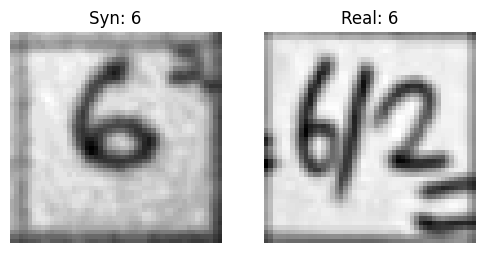

In [69]:
# --- Get first batch ---
syn_images, syn_labels = next(iter(syn_loader))
real_images, real_labels = next(iter(train_loader))

# --- Take first sample ---
syn_img = syn_images[0].squeeze().cpu().numpy()
syn_label = int(syn_labels[0].item()) 

real_img = real_images[0].squeeze().cpu().numpy()
real_label = int(real_labels[0].item())

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(6, 3))

axes[0].imshow(syn_img, cmap='gray')
axes[0].set_title(f"Syn: {syn_label}")
axes[0].axis("off")

axes[1].imshow(real_img, cmap='gray')
axes[1].set_title(f"Real: {real_label}")
axes[1].axis("off")

plt.show()

In [104]:
def visualize_eval(loss, acc, cm):
    print(f"Test Loss: {loss:.4f}, Test Accuracy: {acc:.4f}")
    plt.figure(figsize=(6,5))
    ax = sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', linewidths=0.5, linecolor='black')
    ax.tick_params(axis='both', which='major', labelsize=8)
    plt.xticks(rotation=0)
    plt.yticks(rotation=0)
    for _, spine in ax.spines.items():
        spine.set_visible(True)
        spine.set_linewidth(0.5)
        spine.set_color('black')
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix")
    plt.show()
    
def print_distribution(dataset_name, subset, full_df):
    """
    subset: The Torch Subset object
    full_df: The original dataframe containing the 'label' column
    """
    indices = subset.indices
    raw_labels = full_df.iloc[indices]['label'].values
    labels = np.array([0 if l == '-' else int(l) for l in raw_labels])
    
    unique, counts = np.unique(labels, return_counts=True)
    dist = dict(zip(unique, counts))
    
    print(f"--- {BOLD_L}{dataset_name}{BOLD_R} Distribution (Total: {BOLD_L}{len(labels)}{BOLD_R}) ---")
    for label in sorted(dist.keys()):
        percentage = (dist[label] / len(labels)) * 100
        print(f"  Class {label}: {dist[label]:<6} samples ({percentage:.1f}%)")
    print()

# Usage:
print_distribution("SYN", syn_subset, full_dataset.df)
print_distribution("MIX", mix_subset, full_dataset.df)
print_distribution("FINE-TUNE TRAIN", train_subset, full_dataset.df)
print_distribution("VAL", val_subset, full_dataset.df)
# print_distribution("TEST", test_subset, full_dataset.df)

--- SYN Distribution (Total: 20000) ---
  Class 0: 2383   samples (11.9%)
  Class 1: 2136   samples (10.7%)
  Class 2: 2184   samples (10.9%)
  Class 3: 2041   samples (10.2%)
  Class 4: 2001   samples (10.0%)
  Class 5: 1664   samples (8.3%)
  Class 6: 1774   samples (8.9%)
  Class 7: 2017   samples (10.1%)
  Class 8: 2015   samples (10.1%)
  Class 9: 1785   samples (8.9%)

--- MIX Distribution (Total: 1220) ---
  Class 0: 122    samples (10.0%)
  Class 1: 122    samples (10.0%)
  Class 2: 122    samples (10.0%)
  Class 3: 122    samples (10.0%)
  Class 4: 122    samples (10.0%)
  Class 5: 122    samples (10.0%)
  Class 6: 122    samples (10.0%)
  Class 7: 122    samples (10.0%)
  Class 8: 122    samples (10.0%)
  Class 9: 122    samples (10.0%)

--- FINE-TUNE TRAIN Distribution (Total: 1160) ---
  Class 0: 138    samples (11.9%)
  Class 1: 2      samples (0.2%)
  Class 2: 4      samples (0.3%)
  Class 3: 77     samples (6.6%)
  Class 4: 205    samples (17.7%)
  Class 5: 305    sample

In [87]:
# check leakage between datasets
print(
    len(set(mix_indices) & set(val_indices)),
    # len(set(mix_indices) & set(test_indices)),
    len(set(fine_indices) & set(val_indices)),
    len(set(fine_indices) & set(mix_indices)),
    # len(set(fine_indices) & set(test_indices)),
    # len(set(val_indices) & set(test_indices))
)

0 0 418


In [88]:
# Distribution of pixel intensities between synthetic and real images
img_real, label_real = train_subset[0]
img_syn, label_syn = syn_subset[0]

print("Real mean/std:", img_real.mean().item(), img_real.std().item())
print("Syn  mean/std:", img_syn.mean().item(), img_syn.std().item())

Real mean/std: 0.6276654601097107 0.17505119740962982
Syn  mean/std: 0.5837759375572205 0.06564626842737198


In [89]:
import cnn, focal_loss
importlib.reload(cnn)
importlib.reload(focal_loss)
from cnn import CNN
from focal_loss import FocalLoss

cnn1 = CNN(num_classes=10)
class_weights = torch.tensor(weights, dtype=torch.float32).to(cnn1.device)
cnn1.criterion = nn.CrossEntropyLoss()
cnn1.optimizer = torch.optim.Adam(cnn1.parameters(), lr=5e-3, weight_decay = 5e-5)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    cnn1.optimizer, T_max=6, eta_min=1e-5
)
hist_syn = cnn1.train_loop(syn_loader, val_loader, epochs=6, scheduler=scheduler)

Epoch 1/6:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch 1/6: 100%|██████████| 157/157 [00:20<00:00,  7.68it/s, loss=1.89]


Train Loss: 1.9308 | Train Acc: 25.81% | Val Loss: 4.4999 | Val Acc: 6.92%



Epoch 2/6: 100%|██████████| 157/157 [00:21<00:00,  7.46it/s, loss=1.48] 


Train Loss: 1.3520 | Train Acc: 48.16% | Val Loss: 2.0682 | Val Acc: 35.77%



...

Train Loss: 0.5967 | Train Acc: 79.66% | Val Loss: 3.7959 | Val Acc: 31.15%



Epoch 5/6: 100%|██████████| 157/157 [00:19<00:00,  7.90it/s, loss=0.316]


Train Loss: 0.4049 | Train Acc: 86.86% | Val Loss: 1.9295 | Val Acc: 50.38%



Epoch 6/6: 100%|██████████| 157/157 [00:19<00:00,  8.08it/s, loss=0.486]


Train Loss: 0.3266 | Train Acc: 89.52% | Val Loss: 2.2277 | Val Acc: 49.23%



Test Loss: 2.2277, Test Accuracy: 0.4923


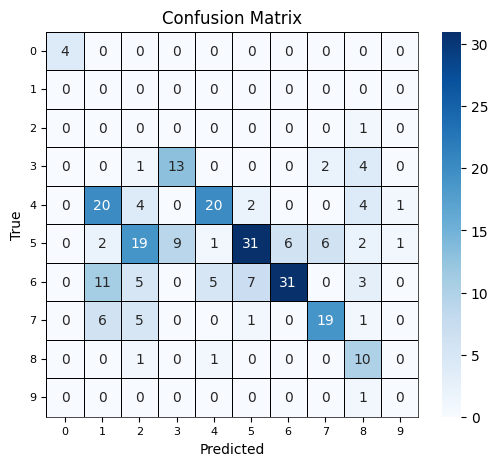

In [90]:
test_loss, test_acc, test_cm = cnn1.evaluate(val_loader, detailed=True)
visualize_eval(test_loss, test_acc, test_cm)

In [74]:
checkpoint = {
    "model_state": cnn1.state_dict(),
    "optimizer_state": cnn1.optimizer.state_dict(),
    "scheduler_state": scheduler.state_dict(),
    "epoch": 6,  # or current epoch
    "model_class": "CNN",
    "num_classes": 10,
    "architecture": str(cnn1),
    "train_loss": hist_syn["train_loss"],
    "train_acc": hist_syn["train_acc"],
    "val_loss": hist_syn["val_loss"],
    "val_acc": hist_syn["val_acc"]
}

scratch_train_path = os.path.join(weights_path, cnn_version)
os.makedirs(scratch_train_path, exist_ok=True)
torch.save(checkpoint, os.path.join(scratch_train_path, "cnn_syn_pretrained.pth"))

In [107]:
cp_syn = torch.load(os.path.join(os.path.join(weights_path, cnn_version), "cnn_syn_pretrained.pth"))
cnn1.load_state_dict(cp_syn["model_state"])
cnn1.optimizer.load_state_dict(cp_syn["optimizer_state"])

C:\Users\PC\AppData\Local\Temp\ipykernel_13628\1222515819.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  cp_syn = torch.load(os.path.join(os.path.join(weights_path, cnn

In [108]:
cnn1.optimizer = torch.optim.Adam(cnn1.parameters(), lr=1e-3, weight_decay=5e-4)
scheduler_mix = torch.optim.lr_scheduler.CosineAnnealingLR(
    cnn1.optimizer, T_max=5, eta_min=1e-6
)
hist_mix = cnn1.train_loop(mix_loader, val_loader, epochs=5, scheduler=scheduler_mix)

Epoch 1/5: 100%|██████████| 39/39 [00:02<00:00, 17.26it/s, loss=1.7]  


Train Loss: 0.7557 | Train Acc: 77.13% | Val Loss: 0.6797 | Val Acc: 77.31%



Epoch 2/5: 100%|██████████| 39/39 [00:02<00:00, 19.40it/s, loss=0.569]


Train Loss: 0.5653 | Train Acc: 82.30% | Val Loss: 0.5776 | Val Acc: 83.46%



Epoch 3/5: 100%|██████████| 39/39 [00:02<00:00, 15.54it/s, loss=0.378]


Train Loss: 0.4678 | Train Acc: 84.51% | Val Loss: 0.8624 | Val Acc: 73.85%



Epoch 4/5: 100%|██████████| 39/39 [00:02<00:00, 14.53it/s, loss=0.135]


Train Loss: 0.4346 | Train Acc: 86.07% | Val Loss: 0.4120 | Val Acc: 88.85%



Epoch 5/5: 100%|██████████| 39/39 [00:02<00:00, 18.83it/s, loss=0.106]


Train Loss: 0.3954 | Train Acc: 87.79% | Val Loss: 0.4034 | Val Acc: 88.46%



In [43]:
print(cnn1.optimizer.param_groups[0]['lr'])

0.0001473001627973195


In [110]:
checkpoint = {
    "model_state": cnn1.state_dict(),
    "optimizer_state": cnn1.optimizer.state_dict(),
    "scheduler_state": scheduler_mix.state_dict(),
    "epoch": 5,
    "model_class": "CNN",
    "num_classes": 10,
    "architecture": str(cnn1),
    "train_loss": hist_mix["train_loss"],
    "train_acc": hist_mix["train_acc"],
    "val_loss": hist_mix["val_loss"],
    "val_acc": hist_mix["val_acc"],
    "desc": "lr=1e-3, weight_decay=5e-4. Cosine Anealing LR scheduler used."
}

torch.save(checkpoint, os.path.join(weights_path, cnn_version, "cnn_mix_pretrained.pth"))

Test Loss: 0.4034, Test Accuracy: 0.8846


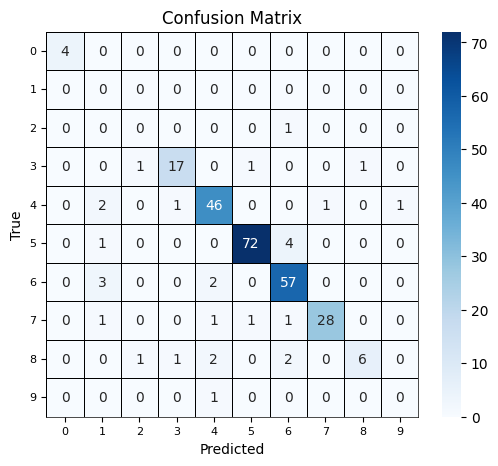

In [109]:
test_loss, test_acc, test_cm = cnn1.evaluate(val_loader, detailed=True)
visualize_eval(test_loss, test_acc, test_cm)

In [266]:
cp_syn = torch.load(os.path.join(os.path.join(weights_path, cnn_version), "cnn_mix_pretrained.pth"))
cnn1.load_state_dict(cp_syn["model_state"])
cnn1.optimizer.load_state_dict(cp_syn["optimizer_state"])

C:\Users\PC\AppData\Local\Temp\ipykernel_20808\3191492691.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  cp_syn = torch.load(os.path.join(os.path.join(weights_path, cnn

In [152]:
cp_syn = torch.load(os.path.join(os.path.join(weights_path, cnn_version), "cnn_mix_pretrained.pth"))
cnn1.load_state_dict(cp_syn["model_state"])
cnn1.optimizer.load_state_dict(cp_syn["optimizer_state"])

C:\Users\PC\AppData\Local\Temp\ipykernel_13628\3191492691.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  cp_syn = torch.load(os.path.join(os.path.join(weights_path, cnn

In [153]:
# cnn1.optimizer = torch.optim.Adam(cnn1.parameters(), lr=5e-5)
cnn1.optimizer = torch.optim.Adam(cnn1.parameters(), lr=5e-4, weight_decay=5e-5)
scheduler_fine = torch.optim.lr_scheduler.CosineAnnealingLR(
    cnn1.optimizer, T_max=8, eta_min=1e-7
)
hist_real = cnn1.train_loop(train_loader, val_loader, epochs=8, scheduler=scheduler_fine)

Epoch 1/8: 100%|██████████| 37/37 [00:02<00:00, 16.86it/s, loss=0.928]


Train Loss: 0.5436 | Train Acc: 83.28% | Val Loss: 0.3117 | Val Acc: 91.54%



Epoch 2/8: 100%|██████████| 37/37 [00:01<00:00, 19.16it/s, loss=0.265]


Train Loss: 0.4126 | Train Acc: 87.24% | Val Loss: 0.4547 | Val Acc: 83.46%



Epoch 3/8: 100%|██████████| 37/37 [00:01<00:00, 22.89it/s, loss=0.097]


...

Train Loss: 0.3027 | Train Acc: 90.69% | Val Loss: 0.2293 | Val Acc: 91.92%



Epoch 7/8: 100%|██████████| 37/37 [00:01<00:00, 18.59it/s, loss=0.052]


Train Loss: 0.2543 | Train Acc: 92.41% | Val Loss: 0.2087 | Val Acc: 94.23%



Epoch 8/8: 100%|██████████| 37/37 [00:01<00:00, 18.79it/s, loss=1.15]  


Train Loss: 0.2764 | Train Acc: 91.90% | Val Loss: 0.2121 | Val Acc: 94.23%



In [157]:
test_loss, test_acc, test_cm = cnn1.evaluate(val_loader, detailed=True)
# visualize_eval(test_loss, test_acc, test_cm)
print(test_cm)

[[ 4  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  1  0  0  0  0]
 [ 0  0 19  1  0  0  0  0  0]
 [ 0  0  1 49  0  0  0  1  0]
 [ 0  0  0  2 74  1  0  0  0]
 [ 0  0  0  2  0 60  0  0  0]
 [ 0  0  0  2  1  0 29  0  0]
 [ 0  0  1  0  1  0  0 10  0]
 [ 0  0  0  1  0  0  0  0  0]]


In [156]:
checkpoint = {
    "model_state": cnn1.state_dict(),
    "optimizer_state": cnn1.optimizer.state_dict(),
    "scheduler_state": scheduler_fine.state_dict(),
    "epoch": 8,
    "model_class": "CNN",
    "num_classes": 10,
    "architecture": str(cnn1),
    "train_loss": hist_real["train_loss"],
    "train_acc": hist_real["train_acc"],
    "val_loss": hist_real["val_loss"],
    "val_acc": hist_real["val_acc"],
    "desc": r"used all real train samples, with 40% already seen in mix phase."
}

torch.save(checkpoint, os.path.join(weights_path, cnn_version, "cnn_real_train.pth"))